# Telemetry Analysis

In [30]:
# Imports
import sys
import importlib
sys.path.append("../..")

import Sliplib.slipload as sl
import Sliplib.selection as slipclassify
import Sliplib.GridSum as grid_sum
import Sliplib.plotting as slplot

importlib.reload(slipclassify)
importlib.reload(grid_sum)

<module 'Sliplib.GridSum' from '/mnt/Windows/Projects_S1/ProjectSlipstream/2026_Austria_GP/notebooks/../../Sliplib/GridSum.py'>

In [31]:
# Select GP and Load Session
session = sl.load_gp(2025,"Austrian Grand Prix","Race")
session.load()

core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '16', '44', '63', '30', '14', '5', '27', '31', '87', '6', '10', 

In [32]:
# Extract Lap Data
R_Laps = session.laps
R_Laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:12:37.412000,NOR,4,0 days 00:01:28.861000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:31.326000,...,True,McLaren,0 days 01:11:08.287000,2025-06-29 13:18:01.080,124,1.0,False,,False,False
1,0 days 01:14:31.838000,NOR,4,0 days 00:01:54.426000,2.0,1.0,NaT,NaT,0 days 00:00:26.438000,0 days 00:00:53.661000,...,True,McLaren,0 days 01:12:37.412000,2025-06-29 13:19:30.205,4,1.0,False,,False,False
2,0 days 01:16:24.860000,NOR,4,0 days 00:01:53.022000,3.0,1.0,NaT,NaT,0 days 00:00:26.434000,0 days 00:00:50.148000,...,True,McLaren,0 days 01:14:31.838000,2025-06-29 13:21:24.631,41,1.0,False,,False,False
3,0 days 01:17:35.114000,NOR,4,0 days 00:01:10.254000,4.0,1.0,NaT,NaT,0 days 00:00:17.564000,0 days 00:00:31.393000,...,True,McLaren,0 days 01:16:24.860000,2025-06-29 13:23:17.653,1,1.0,False,,False,True
4,0 days 01:18:44.972000,NOR,4,0 days 00:01:09.858000,5.0,1.0,NaT,NaT,0 days 00:00:17.488000,0 days 00:00:31.430000,...,True,McLaren,0 days 01:17:35.114000,2025-06-29 13:24:27.907,1,1.0,False,,False,True


In [33]:
# Import Drivers
hul,oco,nor,pia,lec,ham = slipclassify.pick_athletes(R_Laps,["HUL","OCO","NOR","PIA","LEC","HAM"])

# Test
lec.head(10)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
140,0 days 01:12:42.753000,LEC,16,0 days 00:01:34.202000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:32.122000,...,True,Ferrari,0 days 01:11:08.287000,2025-06-29 13:18:01.080,124,3.0,False,,False,False
141,0 days 01:14:34.285000,LEC,16,0 days 00:01:51.532000,2.0,1.0,NaT,NaT,0 days 00:00:24.098000,0 days 00:00:53.387000,...,True,Ferrari,0 days 01:12:42.753000,2025-06-29 13:19:35.546,4,3.0,False,,False,False
142,0 days 01:16:25.878000,LEC,16,0 days 00:01:51.593000,3.0,1.0,NaT,NaT,0 days 00:00:26.530000,0 days 00:00:50.544000,...,True,Ferrari,0 days 01:14:34.285000,2025-06-29 13:21:27.078,41,3.0,False,,False,False
143,0 days 01:17:36.813000,LEC,16,0 days 00:01:10.935000,4.0,1.0,NaT,NaT,0 days 00:00:17.722000,0 days 00:00:31.653000,...,True,Ferrari,0 days 01:16:25.878000,2025-06-29 13:23:18.671,1,3.0,False,,False,True
144,0 days 01:18:47.040000,LEC,16,0 days 00:01:10.227000,5.0,1.0,NaT,NaT,0 days 00:00:17.387000,0 days 00:00:31.363000,...,True,Ferrari,0 days 01:17:36.813000,2025-06-29 13:24:29.606,1,3.0,False,,False,True
145,0 days 01:19:57.250000,LEC,16,0 days 00:01:10.210000,6.0,1.0,NaT,NaT,0 days 00:00:17.441000,0 days 00:00:31.437000,...,True,Ferrari,0 days 01:18:47.040000,2025-06-29 13:25:39.833,1,3.0,False,,False,True
146,0 days 01:21:07.443000,LEC,16,0 days 00:01:10.193000,7.0,1.0,NaT,NaT,0 days 00:00:17.446000,0 days 00:00:31.384000,...,True,Ferrari,0 days 01:19:57.250000,2025-06-29 13:26:50.043,1,3.0,False,,False,True
147,0 days 01:22:17.355000,LEC,16,0 days 00:01:09.912000,8.0,1.0,NaT,NaT,0 days 00:00:17.448000,0 days 00:00:31.269000,...,True,Ferrari,0 days 01:21:07.443000,2025-06-29 13:28:00.236,1,3.0,False,,False,True
148,0 days 01:23:27.478000,LEC,16,0 days 00:01:10.123000,9.0,1.0,NaT,NaT,0 days 00:00:17.561000,0 days 00:00:31.283000,...,True,Ferrari,0 days 01:22:17.355000,2025-06-29 13:29:10.148,1,3.0,False,,False,True
149,0 days 01:24:37.547000,LEC,16,0 days 00:01:10.069000,10.0,1.0,NaT,NaT,0 days 00:00:17.714000,0 days 00:00:31.092000,...,True,Ferrari,0 days 01:23:27.478000,2025-06-29 13:30:20.271,1,3.0,False,,False,True


In [34]:
# Pick the fastest Lap for each
hul_fast,oco_fast,nor_fast,pia_fast,lec_fast,ham_fast = slipclassify.pick_fastest_group([hul,oco,nor,pia,lec,ham])

# Test
oco_fast

Time                      0 days 02:18:44.640000
Driver                                       OCO
DriverNumber                                  31
LapTime                   0 days 00:01:09.550000
LapNumber                                   55.0
Stint                                        3.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:17.489000
Sector2Time               0 days 00:00:30.883000
Sector3Time               0 days 00:00:21.178000
Sector1SessionTime        0 days 02:17:52.587000
Sector2SessionTime        0 days 02:18:23.470000
Sector3SessionTime        0 days 02:18:44.648000
SpeedI1                                    294.0
SpeedI2                                    229.0
SpeedFL                                    275.0
SpeedST                                    296.0
IsPersonalBest                              True
Compound                                    HARD
TyreLife            

In [35]:
# Take out a Summary!
fast_sum = slipclassify.tel_fast_lap_summary([hul_fast,oco_fast,nor_fast,pia_fast,lec_fast,ham_fast])
fast_sum

,Driver,LapTime,Compound,TyreLife
0,HUL,1:09.459,MEDIUM,15.0
1,OCO,1:09.550,HARD,5.0
2,NOR,1:08.272,MEDIUM,9.0
3,PIA,1:07.924,MEDIUM,6.0
4,LEC,1:08.765,MEDIUM,7.0
5,HAM,1:08.628,MEDIUM,3.0


## Telemetry Datas and Graphs

In [36]:
# Get Telemetry Datas
hul_tel,oco_tel,nor_tel,pia_tel,lec_tel,ham_tel = slipclassify.tel_get_for_all([hul_fast,oco_fast,nor_fast,pia_fast,lec_fast,ham_fast])

# Test
lec_tel

,Date,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Time,SessionTime,Distance
0,2025-06-29 14:24:52.418,11384.0,283.0,7,100.0,False,0,car,0 days 00:00:00.132000,0 days 02:17:59.625000,10.376667
1,2025-06-29 14:24:52.737,11512.0,284.0,7,100.0,False,0,car,0 days 00:00:00.451000,0 days 02:17:59.944000,35.542222
2,2025-06-29 14:24:53.097,11631.0,289.0,7,100.0,False,0,car,0 days 00:00:00.811000,0 days 02:18:00.304000,64.442222
3,2025-06-29 14:24:53.297,11631.0,291.0,7,100.0,False,0,car,0 days 00:00:01.011000,0 days 02:18:00.504000,80.608889
4,2025-06-29 14:24:53.657,10553.0,294.0,8,100.0,False,0,car,0 days 00:00:01.371000,0 days 02:18:00.864000,110.008889
...,...,...,...,...,...,...,...,...,...,...,...
255,2025-06-29 14:25:59.458,11460.0,257.0,6,100.0,False,0,car,0 days 00:01:07.172000,0 days 02:19:06.665000,4166.820833
256,2025-06-29 14:25:59.818,10701.0,263.0,7,100.0,False,0,car,0 days 00:01:07.532000,0 days 02:19:07.025000,4193.120833
257,2025-06-29 14:26:00.218,10845.0,269.0,7,100.0,False,0,car,0 days 00:01:07.932000,0 days 02:19:07.425000,4223.009722
258,2025-06-29 14:26:00.657,11136.0,276.0,7,100.0,False,0,car,0 days 00:01:08.371000,0 days 02:19:07.864000,4256.666389


### Plot - 1 (Distance vs Speed)
This part has 2 Plots:
- One for the 2 Contenders
- Other for the Top 4

### HUL VS OCO

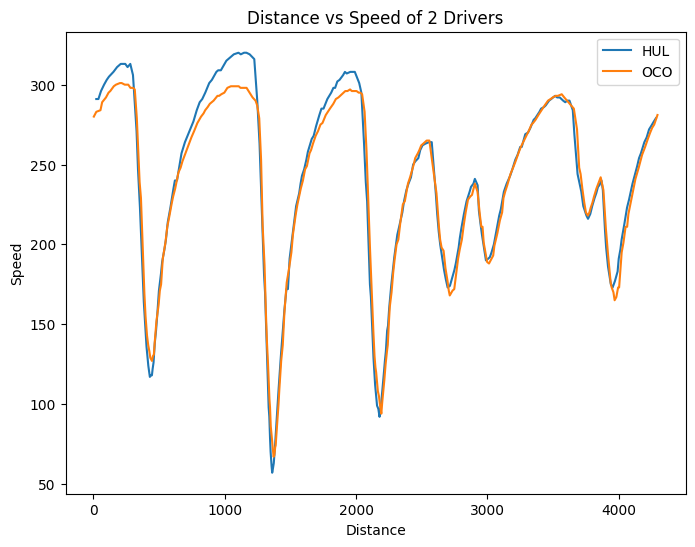

In [37]:
slplot.plot_dist_speed([hul_tel,oco_tel],["HUL","OCO"])

Pretty much distance change is observed between HUL and OCO. Purely HUL dominates and shows an Eye-Witness for such a position Gain

#### Top 4 Plot

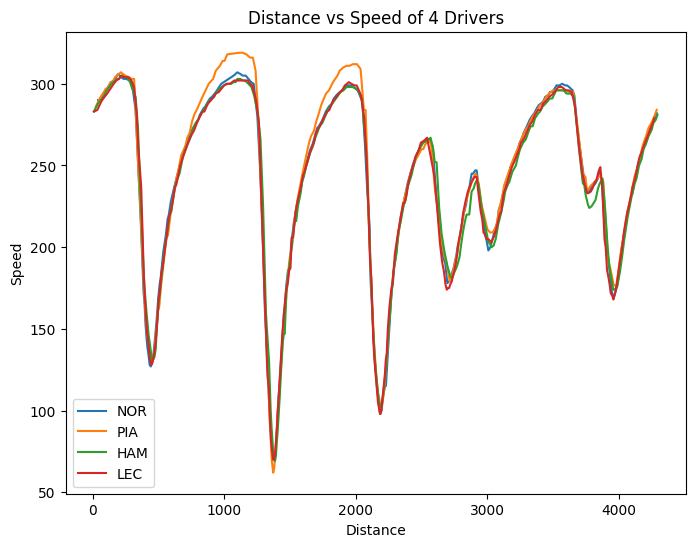

In [38]:
slplot.plot_dist_speed([nor_tel,pia_tel,ham_tel,lec_tel],["NOR","PIA","HAM","LEC"])

From the above Graph! Piastri Has an advantage! He has made the Fastest Lap among the Contenders!

### Plot - 2 (Distance vs Brake)

### HUL vs OCO

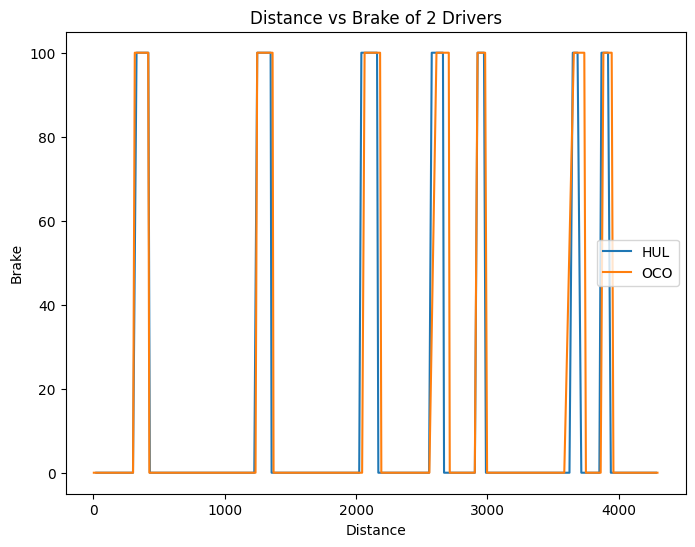

In [39]:
slplot.plot_dist_brake([hul_tel,oco_tel],["HUL","OCO"])

### Top - 4 Plot

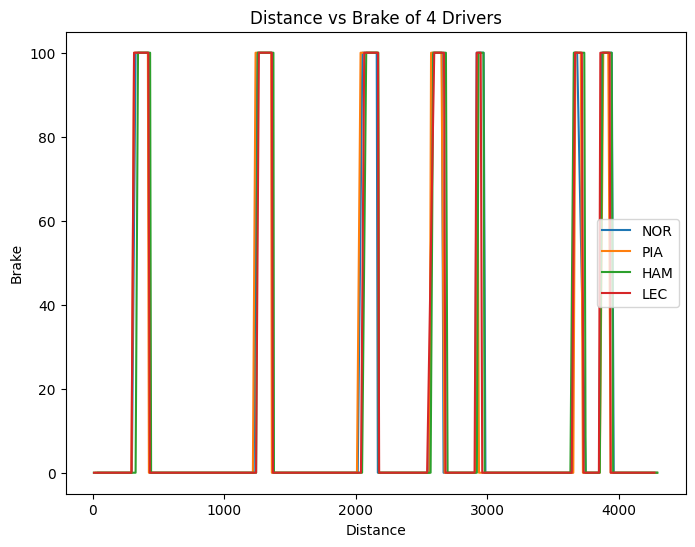

In [41]:
slplot.plot_dist_brake([nor_tel,pia_tel,ham_tel,lec_tel],["NOR","PIA","HAM","LEC"])